# 📊 Financial Impact Analysis
Evaluation of financial impact of ML model & widget implementation vs baseline (Baseline 1: No Widget, Baseline2: Heuristic Model). This notebook looks at the profit lift due to potential increases in AOV & conversion rate and a potential decrease in churn rate. By translating the primary evaluation and model selection metric (Recall@5) into estimated business value, this analysis bridges the gap between model performance and ROI.

### Overview
 1. Imports & Setup
 2. Define Assumptions
 3. Read Inputs (Test Data & Model Evaluation output)
 4. Evaluate Financial Impact for All Models (stacked barplot)
 5. Orchestration (Runs all of the functions)

In [21]:
#Imports
import pandas as pd
import numpy as np
from datetime import datetime
import gcsfs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import bigframes.pandas as bpd
from google.cloud import bigquery

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

from config.config import BUCKET_NAME, BUCKET_PATH, source_loc, output_loc, config_loc, project_id, results_dataset, big_query_loc

sys.path.insert(0, source_loc)
from utilities.utility_functions import get_bq_data_full, select_features, split_data, calculate_metrics_at_k, get_baseline_evaluation_metrics

import warnings
#Suppress warnings to ensure clean notebook
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

pd.options.mode.chained_assignment = None

# --- BigQuery and GCS Configuration ---
bpd.options.bigquery.project = project_id
bpd.options.bigquery.location = big_query_loc
fs = gcsfs.GCSFileSystem()


#### Define Assumptions

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy (Financial Assumptions):</strong> Lacking access to proprietary internal data, this model establishes baseline assumptions using publicly reported metrics. The financial projections are calculated by linking the Recall@5 performance of each model to three core business levers: AOV, conversion rate, and customer churn. In a production environment, these theoretical AOV, conversion, and retention lifts would need to be validated through A/B testing.
</div>

In [2]:
# 1. Company Baselines (Yearly)
ANNUAL_ORDERS = 338800000                            # Instacart publicly reported 2025 Annual Order Volume (According to Gemini) 
BASE_CONVERSION_RATE = 0.06                          # 6% of carts complete checkout (estimate for e-commerce grocery shopping)
ANNUAL_VISITS = ANNUAL_ORDERS/BASE_CONVERSION_RATE   # Annual Platform visits per year
ANNUAL_REVENUE = 3742000000                          # Instacart Publicly Reported Revenue in 2025 from SEC filings (according to Gemini)
BASE_AOV = ANNUAL_REVENUE/ANNUAL_ORDERS              # Revenue per Order
PROFIT_MARGIN = 0.737                                # Instacart's publicly reported profit margin from SEC filings (according to Gemini)
BASE_CHURN_RATE = 0.39                               # 39% of Instacart users churn per year based on Bloomberg Second Measure study (According to Gemini)
ACTIVE_USERS = 14000000                              # Instacart publicly reported monthly active consumers across North America (According to Gemini)
ANNUAL_USER_ORDERS = ANNUAL_ORDERS/ACTIVE_USERS      # Average number of orders placed per active user per year

# 2. Lift based on widget recall performance (per 10% Recall lift)
CONV_LIFT_PER_10_RECALL = 0.002                      # Less customer friction results in a higher rate of completed orders
AOV_LIFT_PER_10_RECALL  = 0.05                       # Increase AOV due to extra items added to the cart (Revenue earned from Instacart price mark-ups, retailer commission fees, and CPC ad-revenue)
CHURN_REDUCTION_PER_10_RECALL = 0.005                 # Reduced churn due to lower customer friction

### Read Inputs

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy (Test Data for Financial Projections):</strong> The financial evaluation is based exclusively on the <strong>test split</strong> (unseen holdout data) rather than the validation set. While hyperparameters and ensemble weights were optimized on the train/val split, the validation set was still utilized for <strong>model selection</strong>. Because the champion model was chosen based on its validation performance, calculating our financial impact on that same data could introduce selection bias and inflate profit lift estimates. By evaluating the financial impact on the unseen test set, we ensure the most unbiased projection of actual production performance.
</div>

In [3]:
#Read in big query data
df_full = get_bq_data_full()
    
#Select Features
df_features, feature_list, sort_list = select_features(df_full)
    
# Split the data exactly as done for base models
_, _, test_df = split_data(df_features)

#Read test results from storage
gcs_path2 = f"{BUCKET_PATH}/evaluation_results/test_results.parquet"
test_results = pd.read_parquet(gcs_path2, filesystem=fs)

Full data shape: (9488394, 39)


### Evaluate Financial Impact for All Models (Including Baseline)

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy (Financial Calculation Methodology):</strong> To translate the primary evaluation metric (Recall@5) into profit lift, I scale the baseline conversion, churn, and AOV assumptions proportionally to the model's performance. For every 10% of Recall achieved, the model applies a fractional lift to these core profit drivers.
    <br><br>
    The total profit lift is calculated by isolating and summing the impact of the three drivers:
    <ul class="modern-list">
        <li><strong>Conversion Lift:</strong> The incremental profit generated from <em>new orders</em>, assuming a higher percentage of carts complete checkout due to better recommendations (Extra Orders × Baseline Profit per Order).</li>
        <li><strong>Retention Lift:</strong> The profit lift from assumed churn reduction due to reduced customer friction during a shopping session(Retained Customers × Annual Profit per Customer).</li>
        <li><strong>AOV Lift:</strong> The profit lift from applying an assumed increase in Average Order Value (due to extra purchases made based on widget recommendations) across baseline orders, the newly converted orders, and the orders from additional retained customers.</li>
</div>

##### Single Model Financial Impact Calculator

In [4]:
def calculate_financials(recall_score, baseline_name, model_type="Baseline"):
    """
    Calculates yearly financial outcomes and profit lifts based on model recall@5 performance 
    impact across average order value (AOV), conversion rate, and customer churn rate.

    Parameters:
    -----------
    recall_score : float
        The Recall@5 evaluation score for the model.
    baseline_name : str
        Name descriptor for the model or baseline configuration.
    model_type : str, default="Baseline"
        Category classification label ('Baseline' or 'Ensemble'/'Model').

    Returns:
    --------
    dict
        A dictionary containing granular annual revenue, profit metrics, and specific lift components.
    """
    
    effective_recall = 0.0 if baseline_name == "No Widget" else recall_score
    recall_units = effective_recall / 0.10

    # 1. --- Baseline Profit ---
    baseline_profit = (ANNUAL_ORDERS) * BASE_AOV * PROFIT_MARGIN
    
    # 2. --- Conversion Impact (Annual Lift) ---
    new_conv_rate = BASE_CONVERSION_RATE + (recall_units * CONV_LIFT_PER_10_RECALL)

    # Calculate the extra orders due to higher conversion rate
    extra_orders = ANNUAL_ORDERS * (new_conv_rate - BASE_CONVERSION_RATE)

    # Calculate Annual Lift from conversion rate increase
    profit_per_order = BASE_AOV * PROFIT_MARGIN
    conversion_profit_lift = extra_orders * profit_per_order

    # 3. --- Annual Retention Impact (Annual Lift)---
    new_churn_rate = BASE_CHURN_RATE - (recall_units * CHURN_REDUCTION_PER_10_RECALL)
    new_churn_rate = max(0.01, new_churn_rate) # Floor churn at 1% to prevent division by 0

    # Calculate the extra customers retained due to lower churn
    extra_customers_retained = ACTIVE_USERS * (BASE_CHURN_RATE - new_churn_rate)
    
    # Calculate Annual Retention Lift
    profit_per_customer = BASE_AOV * ANNUAL_USER_ORDERS * PROFIT_MARGIN
    annual_retention_profit_lift = extra_customers_retained * profit_per_customer

    # 4. --- Calculate AOV Lift ---

    #Calculate AOV Lift from extra orders due to increased conversion rate
    new_aov = BASE_AOV + (recall_units * AOV_LIFT_PER_10_RECALL)
    profit_per_order_new = new_aov * PROFIT_MARGIN
    extra_order_aov_lift = (extra_orders * profit_per_order_new) - conversion_profit_lift

    #Calculate AOV Lift from extra customers due to decreased churn rate
    profit_per_customer_new = new_aov * ANNUAL_USER_ORDERS * PROFIT_MARGIN
    extra_customer_aov_lift = (extra_customers_retained * profit_per_customer_new) - annual_retention_profit_lift

    #Calculate Baseline Lift from increased AOV
    baseline_order_aov_lift = ( ANNUAL_ORDERS * profit_per_order_new) - baseline_profit

    #Calculate Total AOV Lift
    total_aov_profit_lift = extra_order_aov_lift + extra_customer_aov_lift + baseline_order_aov_lift

    # 5. --- Calculate Totals ---
    
    #Caluculate AOV + Conversion & AOV + Retention Profit Lifts (Legacy Columns that are no longer used. Keeping for Power BI Schema)
    aov_conv_profit_lift = conversion_profit_lift + extra_order_aov_lift + baseline_order_aov_lift
    aov_retention_profit_lift = annual_retention_profit_lift + extra_customer_aov_lift

    #Calculate Total Profit and Total Profit Lift
    total_profit_lift = total_aov_profit_lift + conversion_profit_lift + annual_retention_profit_lift
    total_profit = baseline_profit + total_profit_lift

    # 6. --- Create Result Dictionary ---

    result = {"Type": model_type,
              "Model": baseline_name,
              "Recall@5": effective_recall,
              "Baseline_Profit": baseline_profit,
              "AOV_Conv_Profit_Lift": aov_conv_profit_lift,
              "AOV_Retention_Profit_Lift": aov_retention_profit_lift,
              "Conversion_Profit_Lift": conversion_profit_lift,
              "AOV_Profit_Lift": total_aov_profit_lift,
              "Annual_Retention_Profit_Lift": annual_retention_profit_lift,
              "Extra_Order_AOV_Profit_Lift": extra_order_aov_lift,
              "Extra_Customer_AOV_Profit_Lift": extra_customer_aov_lift,
              "Baseline_Order_AOV_Lift": baseline_order_aov_lift,
              "Total_Profit_Lift": total_profit_lift,
              "Total_Annual_Profit": total_profit
             }
    
    return result

##### Evaluate financial impact across all models

In [5]:
def evaluate_financial_impact_all_models():
    """
    Iterates through all evaluated test models and baseline scenarios to compute 
    comprehensive financial impact metrics, percentage gains, and incremental profit lifts 
    relative to both the 'No Widget' and 'Heuristic' baselines.

    Returns:
    --------
    pd.DataFrame
        A sorted dataframe containing financial evaluation metrics ordered by descending Total Profit Lift.
    """
    
    scenarios = [calculate_financials(0.0, "No Widget", "Baseline")]
    
    # Calculate financial impact for every model in test results
    for idx, row in test_results.iterrows():
        scenarios.append(calculate_financials(recall_score=row['Recall@5'], baseline_name=row['Model'], model_type=row['Type']))
    
    df_financials = pd.DataFrame(scenarios)
    
    # Calculate incremental profit lift relative to both baselines (no widget is at index 0; heuristic model is at index 1)
    df_financials['Incremental_Profit_vs_No_Widget'] = df_financials['Total_Annual_Profit'] - df_financials.loc[0, 'Total_Annual_Profit']
    df_financials['Incremental_Profit_vs_Heuristic'] = df_financials['Total_Annual_Profit'] - df_financials.loc[1, 'Total_Annual_Profit']

    # Calculate % profit increase relative to both baselines
    df_financials['Percent_Profit_Increase_vs_No_Widget'] = df_financials['Incremental_Profit_vs_No_Widget']/df_financials.loc[0, 'Total_Annual_Profit']
    df_financials['Percent_Profit_Increase_vs_Heuristic'] = df_financials['Incremental_Profit_vs_Heuristic']/df_financials.loc[1, 'Total_Annual_Profit']
    
    display_cols = ['Type', 'Model', 'Recall@5', 'Baseline_Profit', 'AOV_Conv_Profit_Lift', 'AOV_Retention_Profit_Lift', 'Conversion_Profit_Lift', 
                    'AOV_Profit_Lift', 'Annual_Retention_Profit_Lift', 'Extra_Order_AOV_Profit_Lift', 'Extra_Customer_AOV_Profit_Lift', 'Baseline_Order_AOV_Lift',
                    'Total_Profit_Lift', 'Total_Annual_Profit', 'Incremental_Profit_vs_Heuristic', 'Percent_Profit_Increase_vs_Heuristic',
                    'Incremental_Profit_vs_No_Widget', 'Percent_Profit_Increase_vs_No_Widget']
    
    financial_results_df = df_financials[display_cols].sort_values(by= 'Total_Profit_Lift', ascending=False)

    return financial_results_df

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy (Stacked Profit Distribution):</strong> To effectively communicate the ROI of each model, I utilize a horizontal stacked bar chart. This visualization shows the total profit broken down by each of its drivers—AOV lift, conversion gains, and churn reduction.
</div>

##### Create Stacked barplot to display Results

In [6]:
def create_stacked_bar_chart(financial_results_df, include_baseline = True):
    """
    Generates and renders a styled horizontal stacked bar chart visualizing the individual 
    profit drivers (Baseline Profit, AOV Lift, Churn Reduction Lift, and Conversion Lift) 
    across all models.

    Parameters:
    -----------
    financial_results_df : pd.DataFrame
        Dataframe containing calculated financial impact projections for all models.
    include_baseline : bool, default=True
        Whether to include the foundational base profit segment in the stacked visualization.

    Returns:
    --------
    None
        Renders the matplotlib chart inline.
    """
    
    # 1. Sort the results descending by total profit
    sort_col = 'Total_Annual_Profit' if include_baseline else 'Total_Profit_Lift'
    plot_data = financial_results_df.copy().sort_values(by= sort_col, ascending=False).loc[::-1]
    
    # 2. Isolate the Model as the Index
    plot_data = plot_data.set_index('Model')
    
    # 3. Restructure the columns strictly into the three stacked segments:
    
    if include_baseline:
        
        stacked_df = pd.DataFrame({'Baseline Profit (No Widget)': plot_data['Baseline_Profit'],
                                   'AOV Increase Profit Lift': plot_data['AOV_Profit_Lift'],
                                   'Churn Decrease Profit Lift': plot_data['Annual_Retention_Profit_Lift'],
                                   'Conversion Increase Profit Lift': plot_data['Conversion_Profit_Lift']}, index=plot_data.index)
    else:

        stacked_df = pd.DataFrame({'AOV Increase Profit Lift': plot_data['AOV_Profit_Lift'],
                                   'Churn Decrease Profit Lift': plot_data['Annual_Retention_Profit_Lift'],
                                   'Conversion Increase Profit Lift': plot_data['Conversion_Profit_Lift']}, index=plot_data.index)
        
    
    # 4. Set theme
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(20, 8))
    
    # Draw the stacked bar chart with color theme
    all_colors = ['#d3d3d3', '#85b7e5', '#0056b3', '#26a69a']
    plot_colors = all_colors if include_baseline else all_colors[1:] # Drop the baseline gray
    
    stacked_df.plot(kind='barh', stacked=True, ax=ax, color=plot_colors, edgecolor='black', linewidth=0.5)
    
    # Format the X-axis as Billions of Dollars
    formatter = FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
    ax.xaxis.set_major_formatter(formatter)
    
    # layout, labels, and titles
    if include_baseline:
        title = "Expected Annual Profit by Model"
        xaxis = "Total Annual Gross Profit"
    else:
        title = "Expected Annual Profit Lift by Model"
        xaxis = "Total Annual Gross Profit Lift"
        
    plt.title(title, fontsize=16, fontweight="bold", pad=20)
    plt.xlabel(xaxis, fontsize=12, fontweight="medium", labelpad=10)
    plt.ylabel("")
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=11)
    

    # Position the legend
    ax.legend(title='Profit Drivers', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    
    # Add data labels to the right of each horizontal bar
    for i, (index_name, row) in enumerate(stacked_df.iterrows()):
        total_annual_profit = row.sum()
        
        # Label is placed exactly to the right of the combined stacked bar
        ax.annotate(
            text=f" ${total_annual_profit*1e-6:.3f}M",
            xy=(total_annual_profit, i),
            ha='left', 
            va='center', 
            fontsize=11, 
            fontweight='bold',
            color='black',
            xytext=(5, 0), 
            textcoords='offset points'
        )
    
    # Remove top and right borders
    sns.despine(top=True, right=True, left= False)
    plt.tight_layout()
    plt.show()

    return

### Orchestration

Heuristic Recall@5: 0.2638
Heuristic NDCG@5:   0.3783


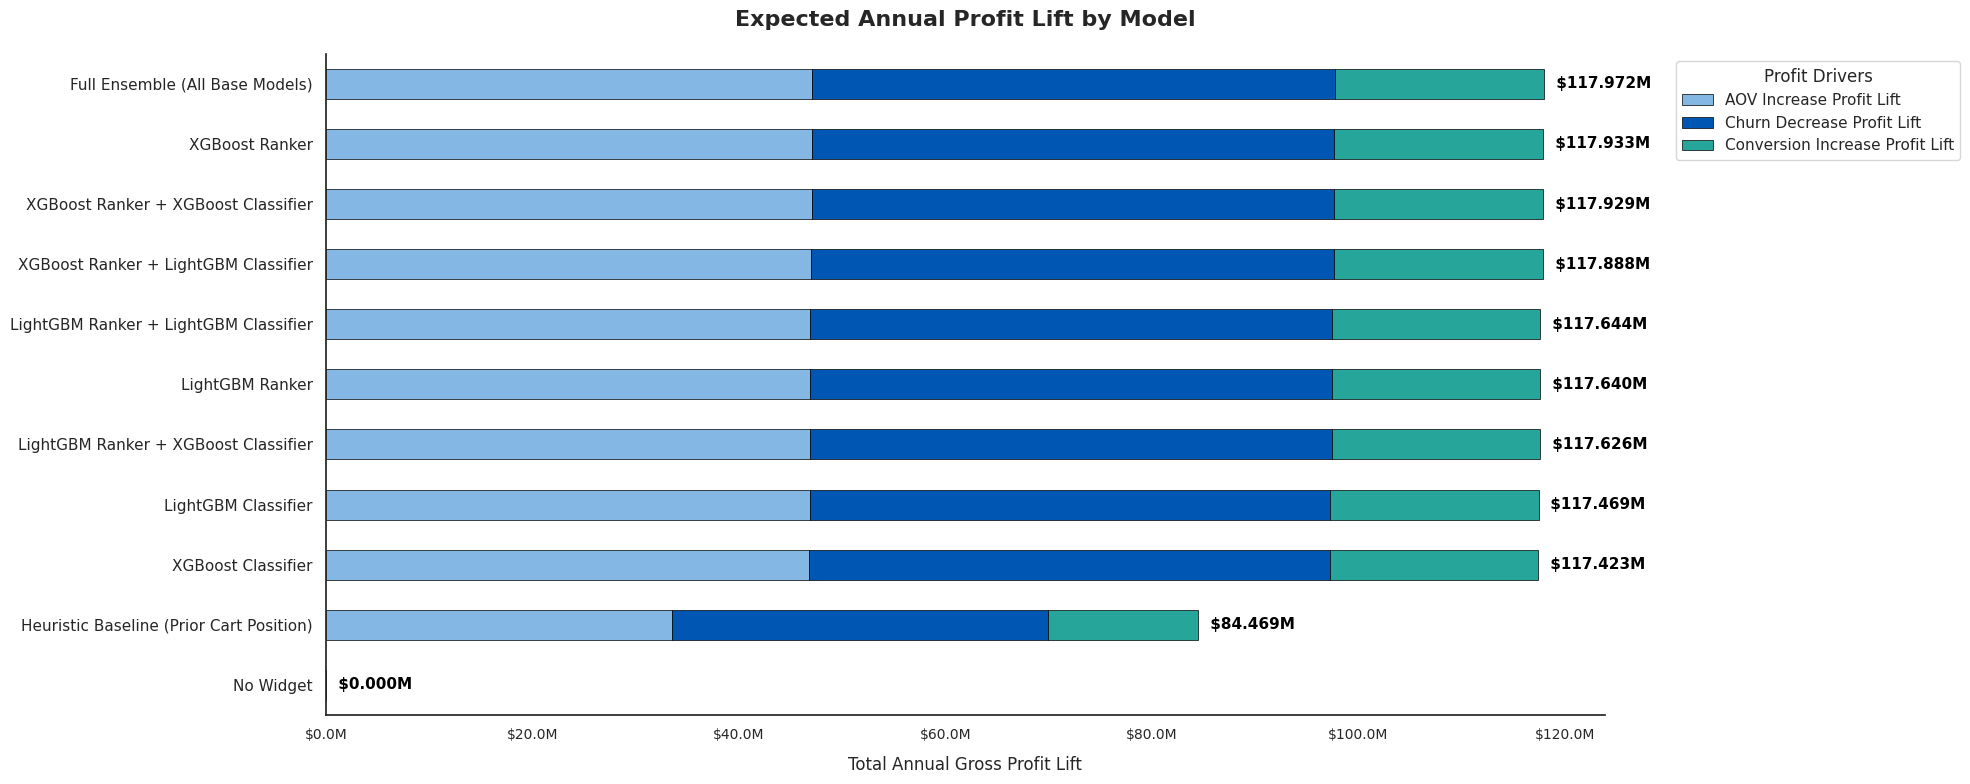

In [7]:
#Calculate Recall@5 and NDCG@5 for heuristic baseline model
_, heuristic_recall, heuristic_ndcg = get_baseline_evaluation_metrics(test_df)

#Calculate profit lift based on model recall@5 impact on aov, conversion rate, and churn for all models (including baseline models)
financial_results_df = evaluate_financial_impact_all_models()

#Create Stacked Bar Chart of Results (Exclude Baseline Profit)
create_stacked_bar_chart(financial_results_df, include_baseline = False)

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights (Financial Evaluation):</strong> 
    <ol class="modern-list"> 
        <li><strong>Significant Lift Over Baselines:</strong> All trained base and ensemble models performed significantly better than the heuristic baseline, translating to an increase in annual profit >~33M annually compared to the heuristic baseline and >117M annually relative to the 'no widget' baseline.</li>
        <li><strong>Model Complexity vs. Marginal Return:</strong> There is only a ~$0.5M annual profit difference between the highest-performing ensemble and the lowest-performing non-baseline ML model. This narrow margin suggests that cross-functional teams should weigh the incremental profit against the increased computational overhead of deploying ensembles in production.</li>
    </ol>
</div>